<a href="https://colab.research.google.com/github/Riteshpaul3/Brain-Tumor-Detection-Python-/blob/main/Lime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import cv2
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf

# Define constants
image_size = 150
labels = ['glioma', 'meningioma', 'notumor', 'pituitary']
X_data = []
Y_data = []

# Use generator-style approach to avoid loading all at once
def load_images_in_batches(base_path, labels, image_size, max_images_per_class=500):
    X = []
    Y = []
    for label in labels:
        count = 0
        for folder in ['Training', 'Testing']:
            folder_path = os.path.join(base_path, folder, label)
            files = os.listdir(folder_path)
            for file in files:
                if count >= max_images_per_class:
                    break
                img_path = os.path.join(folder_path, file)
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.resize(img, (image_size, image_size))
                    X.append(img / 255.0)  # Normalize on the fly
                    Y.append(labels.index(label))
                    count += 1
    return np.array(X, dtype=np.float32), tf.keras.utils.to_categorical(Y, num_classes=len(labels))

# Path to your dataset
base_path = '/content/drive/MyDrive/Final Year Project'

# Load limited number of images per class to avoid RAM crash
X_data, Y_data = load_images_in_batches(base_path, labels, image_size, max_images_per_class=500)


In [ ]:
X_data, Y_data = shuffle(X_data, Y_data, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_data, Y_data, test_size=0.1, random_state=42)

In [ ]:
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.3))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(Dropout(0.3))
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.3))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.3))
model.add(Conv2D(128, (3, 3), activation='relu', name='last_conv'))  # Name this for Grad-CAM
model.add(Conv2D(256, (3, 3), activation='relu'))
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(4, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 146, 146, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 73, 73, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 73, 73, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 71, 71, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 69, 69, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 69, 69, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 34, 34, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 34, 34, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,447,044 (16.96 MB)

 Trainable params: 4,447,044 (16.96 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 352s 7s/step - accuracy: 0.3105 - loss: 1.3803 - val_accuracy: 0.2333 - val_loss: 1.5107
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 375s 7s/step - accuracy: 0.3746 - loss: 1.2286 - val_accuracy: 0.4667 - val_loss: 1.0744
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 375s 7s/step - accuracy: 0.4171 - loss: 1.1835 - val_accuracy: 0.4889 - val_loss: 1.0911
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 389s 7s/step - accuracy: 0.6642 - loss: 0.8311 - val_accuracy: 0.7500 - val_loss: 0.6393
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 340s 7s/step - accuracy: 0.8095 - loss: 0.5247 - val_accuracy: 0.7833 - val_loss: 0.5408
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 375s 7s/step - accuracy: 0.8381 - loss: 0.4202 - val_accuracy: 0.8056 - val_loss: 0.4629
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 352s 7s/step - accuracy: 0.8735 - loss: 0.3523 - val_accuracy: 0.8944 - val_loss: 0.3412
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 367s 7s/step - accuracy: 0.8672 - loss: 0.3710 - val_accuracy: 0.9222 - v

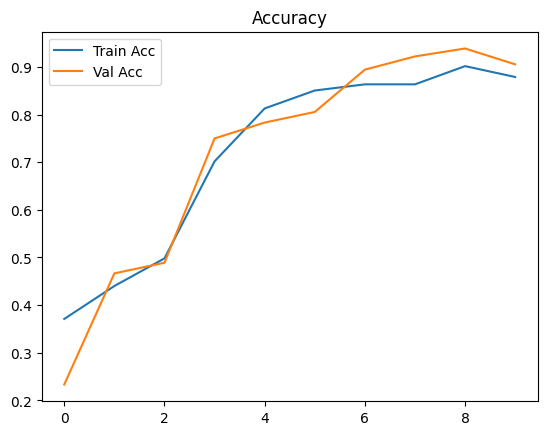

In [ ]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.show()

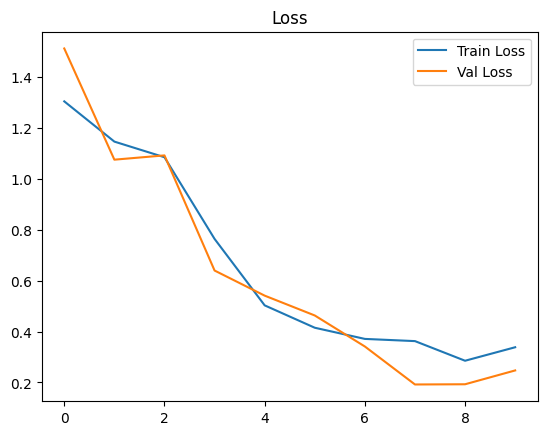

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [ ]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt

# Define a prediction function for LIME
def predict_fn(images):
    images = np.array(images)
    return model.predict(images)

# Create a LIME image explainer
explainer = lime_image.LimeImageExplainer()

# Choose a test image index to explain
idx = 30
test_image = X_test[idx]
test_image_np = np.expand_dims(test_image, axis=0)

# Explain the prediction on the chosen image
explanation = explainer.explain_instance(
    test_image.astype('double'),          # the image to explain
    predict_fn,                           # prediction function
    top_labels=4,                         # explain top 4 predictions
    hide_color=0,                         # background color
    num_samples=1000                      # number of perturbed samples
)

# Get explanation mask and display it
temp, mask = explanation.get_image_and_mask(
    label=explanation.top_labels[0],      # the label to show
    positive_only=True,
    num_features=10,
    hide_rest=False
)

# Show explanation
plt.figure(figsize=(6, 6))
plt.title(f'LIME Explanation - Predicted: {labels[explanation.top_labels[0]]}')
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.axis('off')
plt.show()


ModuleNotFoundError: No module named 'lime'

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Select an index from the test set
idx = 30  # Change index to visualize different samples
img = X_test[idx]  # Get the image from test set

# Create a LIME image explainer
explainer = lime_image.LimeImageExplainer()

# Define prediction function (model expects a batch)
predict_fn = lambda x: model.predict(x)

# Explain the prediction
explanation = explainer.explain_instance(
    img.astype('double'),       # Image to explain
    predict_fn,                 # Prediction function
    top_labels=4,
    hide_color=0,
    num_samples=1000
)

# Get explanation mask
lime_img, mask = explanation.get_image_and_mask(
    label=explanation.top_labels[0],  # Predicted class
    positive_only=True,
    num_features=10,
    hide_rest=False
)

# Plot Original and Explanation
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"LIME Explanation - Predicted: {labels[explanation.top_labels[0]]}")
plt.imshow(mark_boundaries(lime_img / 255.0, mask))
plt.axis('off')

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'lime'

In [ ]:
predicted_label = labels[np.argmax(model.predict(test_image_np))]
true_label = labels[np.argmax(y_test[idx])]
print(f"True Label: {true_label}")
print(f"Predicted Label: {predicted_label}")

NameError: name 'labels' is not defined